<h1>Sarcasm detection system using custom
Naïve Bayes implementations</h1>

In [9]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
import math 
from collections import defaultdict, Counter
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [10]:
student_ID = 276690
last_6     = student_ID % 1000000
seed       = last_6 % 100000

In [11]:
df = pd.read_json('/Users/arjun/Downloads/Data/Sarcasm_Headlines_Dataset_v2.json', lines=True)
print(df.shape)
df.head()

(28619, 3)


,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [12]:
#shuffling
df_shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)
df_shuffled.head()

,is_sarcastic,headline,article_link
0,1,woman walking alone at night picks up pace aft...,https://local.theonion.com/woman-walking-alone...
1,0,exxon mobil told to hand over decades of clima...,https://www.huffingtonpost.com/entry/exxon-mas...
2,0,top german soccer team hit in explosions,https://www.huffingtonpost.com/entry/borussia-...
3,0,assad's forces take 'capital of revolution',https://www.huffingtonpost.com/entry/assad-tak...
4,1,you to receive 15 pounds of venison sausage fr...,https://www.theonion.com/you-to-receive-15-pou...


In [13]:
#70/15/15 split 
n = len(df_shuffled)
training_upper_lim = int(0.7 * n)
validation_upper_lim = int(0.85 * n)
training_dataset = df_shuffled.iloc[: training_upper_lim]
validation_dataset = df_shuffled.iloc[training_upper_lim:validation_upper_lim]
test_dataset = df_shuffled.iloc[validation_upper_lim:]

In [14]:
print(n)
print(f'train dataset count : {len(training_dataset)}')
print(f'validation dataset count : {len(validation_dataset)}')
print(f'test dataset count : {len(test_dataset)}')
total = len(training_dataset) + len(validation_dataset) + len(test_dataset)
print(f'{'count verified'if total ==n else 'mismatch in count'}')




28619
train dataset count : 20033
validation dataset count : 4293
test dataset count : 4293
count verified


In [15]:
#smoothing
smoothing_sets = {
    0: [0, 0.1, 1],
    1: [0, 0.5, 2],
    2: [0, 1,   5],
}
k = seed % 4 
smoothing_key    = seed % 3
selected_alphas  = smoothing_sets[smoothing_key]

**Task 1 – Tokenisation & Preprocessing**

In [16]:
#basic cleaning
def basic_cleaning (text):
     text = text.lower() #remove stand alone number
     text = re.sub(r"<.*?>","", text) #html
     text = re.sub(r'[?!]*\?[!]+[?!]*|[?!]*![?]+[?!]*', '[INT_MARK]', text)
     text = re.sub(r'!{2,}','[EXC_SEQ]',  text) #Exclamation Sequences: !!, !!!, etc. à[EXC_SEQ]
     text = re.sub(r'\?{2,}','[QUE_SEQ]',  text)  #Question Sequences: ??, ???, etc. à[QUE_SEQ]
     text = re.sub(r'\.{3,}',   '[ELLIP]',    text) #Ellipses: ... à [ELLIP]

     text = re.sub(r"[^\w\s'\[\]]", "", text)  # remove non word/space/apostrophe
     text = re.sub(r"(?<!\w)'|'(?!\w)", '', text)  # remove apostrophes NOT inside words

     text = re.findall(r'\[.*?\]|\w+(?:\'\w+)*', text)
     return text
     

references:
https://www.geeksforgeeks.org/python/how-to-remove-html-tags-from-string-in-python/

https://regex101.com/

https://docs.python.org/3/library/re.html#re.sub #pattern substitution


In [17]:
df_shuffled['headline'].iloc[1]

'exxon mobil told to hand over decades of climate documents in major legal blow'

In [18]:
#testing regex
sample_headlines = [
    "Scientists DISCOVER!!! That Water Is WET!!",   
    "Are? you?? serious????",             
    "Oh reaLly?! come on!!??",      
    "just waiting...",    
    "<b>Breaking news</b>: bomb blast", 
    "senate's new plan to [repeal] but not replace",  
    "a 'damn' letter from a serial killer",    
]

data=[]
for i in sample_headlines:
    word = basic_cleaning(i)
    print(word)




['scientists', 'discover', '[EXC_SEQ]', 'that', 'water', 'is', 'wet', '[EXC_SEQ]']
['are', 'you', '[QUE_SEQ]', 'serious', '[QUE_SEQ]']
['oh', 'really', '[INT_MARK]', 'come', 'on', '[INT_MARK]']
['just', 'waiting', '[ELLIP]']
['breaking', 'news', 'bomb', 'blast']
["senate's", 'new', 'plan', 'to', '[repeal]', 'but', 'not', 'replace']
['a', 'damn', 'letter', 'from', 'a', 'serial', 'killer']


**Step 2 – Negation Handling**

In [19]:
#Negation Handling
negation_words={ "not", "no", "never", "don't", "didn't", "isn't", "wasn't"}
stop_words={"the", "a","also","an","and","are","as","at","be","because","been","but",
            "by","for","from","has","have","however","if","in","is","of",
            "on","or","so","than","that","their","there","these","this","to","was","were"}
vowels = set('aeiou')

def count_vowels(token):
    return sum(1 for ch in token if ch in vowels )
    
def negation_handling(tokens):
    result = []
    i = 0
    while i < len(tokens):
        token = tokens[i]
        if token in negation_words:
            result.append(token)
            n_vowels = count_vowels(token)
            i += 1
            for _ in range(n_vowels):
                if i < len(tokens):
                    result.append("NOT_" + tokens[i])
                    i += 1
        else:
            result.append(token)
            i += 1
    return result
    


In [20]:

def stopword_removal(tokens):
    return [t for t in tokens if t.startswith("NOT_") or t not in stop_words]
 
 
def generate_ngrams(tokens):
    unigrams = tokens
    bigrams  = [f"{tokens[i]}__{tokens[i+1]}" for i in range(len(tokens) - 1)] #double underscore
    return unigrams + bigrams
 

In [21]:
def replace_oov(tokens, vocab):
    return [t if t in vocab else "<UNK>" for t in tokens]

In [22]:
def preprocess(text, vocab=None, ablation_k=None):
    tokens = basic_cleaning(text)

    if ablation_k != 2:
        tokens = negation_handling(tokens)

    if ablation_k != 3:
        tokens = stopword_removal(tokens)

    all_tokens = generate_ngrams(tokens)

    if ablation_k == 0:
        all_tokens = [t for t in all_tokens if "_" in t]
    elif ablation_k == 1:
        all_tokens = [t for t in all_tokens if "_" not in t]

    if vocab is not None:
        all_tokens = replace_oov(all_tokens, vocab)

    return all_tokens

**Step 5 – OOV Handling**

In [23]:
#OOV Handling 

train_tokens = training_dataset["headline"].apply(lambda x: preprocess(x))
vocab            = set(tok for doc in train_tokens for tok in doc)
train_tokens = training_dataset["headline"].apply(lambda x: preprocess(x, vocab))
val_tokens   = validation_dataset["headline"].apply(lambda x: preprocess(x, vocab))
test_tokens  = test_dataset["headline"].apply(lambda x: preprocess(x, vocab))

In [24]:


val_tokens.head()


20033    [two, nonbinary, college, activists, creating,...
20034    [jill, <UNK>, saw, <UNK>, singer's, divorce, c...
20035    [study, major, shift, media, landscape, occurs...
20036    [new, healthier, menu, features, food, wendy's...
20037    [bob, dole, picked, off, large, hawk, circling...
Name: headline, dtype: object

In [25]:
test_tokens.head()

24326    [wildfires, force, colorado, <UNK>, rocky, mou...
24327    [best, chance, defeat, roy, moore, may, democr...
24328                          [pentagon, planning, <UNK>]
24329    [no, NOT_more, adult, conversations, prayers, ...
24330    [alabama, native, channing, tatum, encourages,...
Name: headline, dtype: object

In [26]:
train_tokens.head()

0    [woman, walking, alone, night, picks, up, pace...
1    [exxon, mobil, told, hand, over, decades, clim...
2    [top, german, soccer, team, hit, explosions, t...
3    [assad's, forces, take, capital, revolution, a...
4    [you, receive, 15, pounds, venison, sausage, u...
Name: headline, dtype: object

<h1>Task 2 – Manual Feature Representation</h1>

In [27]:
#Compute Document Frequency
def compute_doc_freq(tokenised_doc):
    doc_freq_count ={}
    for doc in tokenised_doc:
        for tkn in set(doc): #to remove th duplicates
            doc_freq_count[tkn]= doc_freq_count.get(tkn,0) + 1

    return doc_freq_count
doc_freq_count = compute_doc_freq(train_tokens.tolist())

#print(doc_freq_count)

In [28]:
#Rare Word Filtering
#Count Vectoriser
t = (seed % 6) + 2 #this clean up the noise, any word appearing less than t value will be removed

print(f"seed: {seed}")
print(f"seed mod 6: {seed % 6}")
print(f"threshold: {t}")

seed: 76690
seed mod 6: 4
threshold: 6


In [29]:
#sorting in alphabetical order
filtered_tokens = [token for token, count in doc_freq_count.items() if count >= t]
filtered_tokens = sorted(filtered_tokens)
#print(filtered_tokens)

In [30]:
#prime position indexing
def find_prime_number(n):
    prime_list =[True]* (n+1)
    prime_list[0]=False
    prime_list[1]=False
    for i in range(2, int(n**0.5)+1):
        if prime_list[i]:
            for j in range(i*i,n+1,i):
                prime_list[j]=False
    return {i for i in range(2,n+1) if prime_list[i]}
primes_list = find_prime_number(len(filtered_tokens) +10) #buffer added just in case

feature_map = {0: "NON_PRIME"} # colomn 0 is always not prime
for position, token in enumerate(filtered_tokens,start=1):
    if position in primes_list:
        feature_map[position] =token #seperate  colomns for prime number
colomn_order = sorted(feature_map.keys())
prime_positions = set(feature_map.keys()) - {0} #since 0 is already non prime
token_matrix = {tkn: pos for pos,tkn in enumerate(filtered_tokens,start=1)}

In [31]:
print(f"Column 0: {feature_map[0]}")
print(f"Column 2: {feature_map.get(2)}")
print(f"col 0 in prime_positions: {0 in prime_positions}")
print(f"col 2 in prime_positions: {2 in prime_positions}") 

Column 0: NON_PRIME
Column 2: 10
col 0 in prime_positions: False
col 2 in prime_positions: True


In [32]:


#needed some changes in the above code , Vocab size is only 5299/28000 headlines which is very low




In [33]:
def build_count_matrix(tokenised_docs):
    rows=[]
    for doc in tokenised_docs:
        counts = {}
        for token in doc:
            pos=token_matrix.get(token)
            if pos is None:
                continue
            if pos in prime_positions:
                counts[pos]=counts.get(pos,0) +1
            else:
                counts[0] = counts.get(0,0) +1
        rows.append([counts.get(c,0) for c in colomn_order])
    return np.array(rows)


In [34]:
train_data_matrix = build_count_matrix(train_tokens.tolist())
test_data_matrix = build_count_matrix(test_tokens.tolist())
validation_data_matrix = build_count_matrix(val_tokens.tolist())


In [35]:
print(f"train_count: {train_data_matrix.shape}")
print(f"val_count: {test_data_matrix.shape}")
print(f"test_count: {validation_data_matrix.shape}")

train_count: (20033, 771)
val_count: (4293, 771)
test_count: (4293, 771)


**B. TF-IDF**

In [36]:
def compute_tf(doc):
    tf ={}
    total_words = len(doc) if len(doc) > 0 else 1
    for tkn in doc :
        tf[tkn]= tf.get(tkn,0) +1
    for tkn in tf:
        tf[tkn] = tf[tkn]/total_words
    return tf

def compute_idf(df_count, n):
    idf ={}
    for tkn,doc_freq in df_count.items():
        idf[tkn]=math.log((n+1)/(doc_freq+1)) +1
    return idf

num_train_docs = len(training_dataset)
idf = compute_idf(doc_freq_count, num_train_docs)
sample_words = list(idf.items())[:5]
for word, score in sample_words:
    print(f"  '{word}' => IDF = {score:.4f}")

  'truck__full' => IDF = 10.2120
  'after' => IDF = 4.3613
  'night__picks' => IDF = 10.2120
  'full' => IDF = 6.8276
  'woman' => IDF = 5.0530


In [37]:
def compute_tf_idf(tokenised_docs, idf, filtered_tokens):
    tkn_index = {t: i for i, t in enumerate(filtered_tokens)}
    rows = []
    for doc in tokenised_docs:
        vct = np.zeros(len(filtered_tokens))
        tf  = compute_tf(doc)
        for tkn, tf_score in tf.items():
            if tkn in tkn_index:     
                index      = tkn_index[tkn]
                idf_score  = idf.get(tkn, 0)
                vct[index] = tf_score * idf_score
        rows.append(vct)
    return np.array(rows)

# TF-IDF
train_tf_idf = compute_tf_idf(train_tokens.tolist(), idf, doc_freq_count)
val_tf_idf   = compute_tf_idf(val_tokens.tolist(),   idf, doc_freq_count)
test_tf_idf  = compute_tf_idf(test_tokens.tolist(),  idf, doc_freq_count)

print(f"{train_tf_idf.shape}")
print(f"tfidf matrix : {train_tf_idf[0][:10].round(4)}") #first 


(20033, 145956)
tfidf matrix : [0.3294 0.1407 0.3294 0.2202 0.163  0.2536 0.3294 0.3294 0.3294 0.2536]


**C. Using the training dataset, report the top 10 tokens with the highest Document**

In [38]:
top10 = sorted(doc_freq_count.items(), key=lambda x: -x[1])[:10]
top10_df = pd.DataFrame(top10, columns=['Token', 'Document Frequency'])
print(top10_df.to_string(index=False))


Token  Document Frequency
 with                1366
  new                1143
trump                 996
  man                 941
about                 766
  you                 699
after                 694
  out                 606
   up                 598
   it                 586


<h1> Task 3 — Naive Bayes Variants</h1>

**A. Multinomial NB**

In [39]:
y_train = training_dataset['is_sarcastic'].values
y_val   = validation_dataset['is_sarcastic'].values
y_test  = test_dataset['is_sarcastic'].values

def evaluate(y_true, y_pred, label=''):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1m = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    print(f'{label} Acc={acc:.4f} F1={f1:.4f} F1-sarc={f1m:.4f}')
    return acc, f1, f1m


In [40]:
def train_multinomial_nb(X_train, X_val, y_train, y_val, alphas):
    #Log Priors
    p_non_sarc = np.mean(y_train==0)
    p_sarc = np.mean(y_train == 1)
    
    #log space
    p_non_sarc_log = np.log(p_non_sarc)
    p_sarc_log = np.log(p_sarc)
    
    #Estimate likelihoods
    best_alpha = None
    best_f1=-1
    best_ll_non_sarc= None
    best_ll_sarc = None,
    
    for alpha in alphas:
        num_features = X_train.shape[1] 
        
        if alpha == 0:
            alpha = 1e-10 
        
        # non sarcasm class
        non_sarc_matrix = X_train[y_train == 0] #boolean indexing- only non sarcastic
        counts_non_sarc = non_sarc_matrix.sum(axis=0) #across all non sarcastic headline, how many times does each token appear - summing rows
        total_non_sarc  = counts_non_sarc.sum()
        ll_non_sarc = np.log( (counts_non_sarc + alpha) / (total_non_sarc + alpha * num_features) )
        
        # sarcasm class  
        sarc_matrix = X_train[y_train == 1] 
        counts_sarc = sarc_matrix.sum(axis=0)
        total_sarc  = counts_sarc.sum()
        ll_sarc = np.log( (counts_sarc + alpha) / (total_sarc + alpha * num_features) )
        
        # Validation predictions
        scores_non_sarc = p_non_sarc_log + X_val @ ll_non_sarc
        scores_sarc = p_sarc_log + X_val @ ll_sarc 
        y_pred = (scores_sarc > scores_non_sarc).astype(int) #predicts whichever class scores higher
        
        acc, f1, f1m = evaluate(y_val, y_pred, f'alpha={alpha}')
        #f1 better compared to accuracy since our data is imbalanced
        if f1 > best_f1:
            best_f1 = f1
            best_alpha = alpha
            best_ll_non_sarc = ll_non_sarc
            best_ll_sarc = ll_sarc
    
    return best_ll_non_sarc, best_ll_sarc, p_non_sarc_log, p_sarc_log



ll_non_sarc, ll_sarc, p_non_srac_log, p_sarc_log = train_multinomial_nb(train_data_matrix,validation_data_matrix,y_train,y_val,selected_alphas)

# Test
test_scores_non_sarc = p_non_srac_log + test_data_matrix @ ll_non_sarc
test_scores_sarc = p_sarc_log + test_data_matrix @ ll_sarc
y_test_pred = (test_scores_sarc > test_scores_non_sarc).astype(int)


evaluate(y_test, y_test_pred, 'Multinomial NB Test')



alpha=1e-10 Acc=0.6266 F1=0.6034 F1-sarc=0.5075
alpha=0.5 Acc=0.6273 F1=0.6040 F1-sarc=0.5080
alpha=2 Acc=0.6280 F1=0.6041 F1-sarc=0.5069
Multinomial NB Test Acc=0.6212 F1=0.5973 F1-sarc=0.4991


(0.6212438853948288, 0.5972907017798916, 0.49907578558225507)

**B. Bernoulli NB**

In [41]:
train_binary   = (train_data_matrix > 0).astype(int)
val_binary     = (validation_data_matrix > 0).astype(int)
test_binary    = (test_data_matrix > 0).astype(int)

p_non_sarc = np.mean(y_train==0)
p_sarc = np.mean(y_train == 1)
p_non_sarc_log = np.log(p_non_sarc)
p_sarc_log = np.log(p_sarc)

In [42]:
best_alpha_bern=None
best_f1_bern = -1
best_ll_non_sarc_bern= None
best_ll_sarc_bern = None

for alpha in selected_alphas:
    num_features = train_binary.shape[1]
    if alpha == 0:
        alpha = 1e-10 #0 causing error, so assigned a smaller value

    #non sarcasm
    non_sarc_matrix = train_binary[y_train == 0] #Non-sarcasm: P(word present | non-sarcastic)
    present_non_sarc = non_sarc_matrix.sum(axis=0)  # #docs containing each word
    docs_non_sarc = non_sarc_matrix.shape[0] #number of rows in matrix
    ll_non_sarc = np.log( (present_non_sarc + alpha) / (docs_non_sarc + 2*alpha) )
    
    #sarcasm
    sarc_matrix = train_binary[y_train == 1]
    present_sarc = sarc_matrix.sum(axis=0)
    docs_sarc = sarc_matrix.shape[0]
    ll_sarc = np.log( (present_sarc + alpha) / (docs_sarc + 2*alpha) )
    
    
    ll_absent_non_sarc = np.log(1 - np.exp(ll_non_sarc))
    ll_absent_sarc     = np.log(1 - np.exp(ll_sarc))
    
    # Validation: present*ll_present + abscent*ll_abscent
    scores_non_sarc = (p_non_sarc_log + val_binary @ ll_non_sarc + (1-val_binary) @ ll_absent_non_sarc)
    
    scores_sarc = (p_sarc_log + val_binary @ ll_sarc + (1-val_binary) @ ll_absent_sarc)
    
    y_pred = (scores_sarc > scores_non_sarc).astype(int) #predicts which class is higher
    
    acc, f1, f1m = evaluate(y_val, y_pred, f'alpha={alpha}')
    
    if f1 > best_f1_bern:
        best_f1_bern = f1
        best_alpha_bern = alpha
        best_ll_non_sarc_bern = (ll_non_sarc, ll_absent_non_sarc)
        best_ll_sarc_bern = (ll_sarc, ll_absent_sarc)

alpha=1e-10 Acc=0.6289 F1=0.6064 F1-sarc=0.5121
alpha=0.5 Acc=0.6294 F1=0.6068 F1-sarc=0.5124
alpha=2 Acc=0.6296 F1=0.6063 F1-sarc=0.5105


In [43]:
#testing best model
(ll_non_sarc_bern, ll_absent_non_bern) = best_ll_non_sarc_bern #ll_absent_non_bern -tkn that doesn't show up in headline
(ll_sarc_bern, ll_absent_sarc_bern) = best_ll_sarc_bern

test_scores_non_sarc = (p_non_sarc_log + test_binary @ ll_non_sarc_bern + (1-test_binary) @ ll_absent_non_bern)
test_scores_sarc = (p_sarc_log + test_binary @ ll_sarc_bern + (1-test_binary) @ ll_absent_sarc_bern)
y_test_pred_bern = (test_scores_sarc > test_scores_non_sarc).astype(int)
evaluate(y_test, y_test_pred_bern, 'Bernoulli NB Test')

Bernoulli NB Test Acc=0.6210 F1=0.5983 F1-sarc=0.5029


(0.6210109480549733, 0.5983362670088053, 0.5029025358997862)

<h1>Numeric Feature Engineering</h1>

<h1>Task 4 – Numeric Meta-Features & Imputation</h1>

In [44]:
def extract_num_features(df):
    num_features = pd.DataFrame(index=df.index)
    num_features['word_count'] = df['headline'].str.split().str.len()
    num_features['char_len'] = df['headline'].str.len()
    num_features['upper_count'] = df['headline'].str.count(r'\b[A-Z]+\b')
    num_features['excl_count'] = df['headline'].str.count('!')
    num_features['ques_count'] = df['headline'].str.count(r'\?')
    num_features['neg_count'] = df['headline'].str.lower().str.count('|'.join(negation_words))
    num_features['sarc_ratio'] = np.where( num_features['word_count'] > 0,num_features['upper_count'] / num_features['word_count'],0.5) # Sarcasm ratio
    
    return num_features
    

train_features = extract_num_features(training_dataset)
val_features = extract_num_features(validation_dataset)
test_features = extract_num_features(test_dataset)

**A. Inject Missing Values**

In [45]:
def inject_missing(df, missing_rate=0.05):
    df  = df.copy().astype(float)
    rand_num_gen = np.random.default_rng(seed) 
    total_cells = df.shape[0] * df.shape[1]
    num_missing   = int(total_cells * missing_rate) #calculation for 5% total
    forced_row = int(rand_num_gen.integers(0, len(df))) #pick a random row number
    df.iat[forced_row, df.columns.get_loc('sarc_ratio')] = np.nan #set that colomn to NaN
    num_missing -= 1 

    all_cells = [
        (r, c)
        for r in range(df.shape[0])
        for c in range(df.shape[1])
    ]

    chosen = rand_num_gen.choice(len(all_cells), size=num_missing, replace=False)
    #loop through row and colomn to set the cell to NaN
    for idx in chosen:
        r, c = all_cells[idx]
        df.iat[r, c] = np.nan      
    return df

train_features_miss = inject_missing(train_features.copy())
val_features_miss = inject_missing(val_features.copy())
test_features_miss = inject_missing(test_features.copy())
print(train_features_miss.isna().sum())

word_count      954
char_len        996
upper_count    1016
excl_count     1062
ques_count      999
neg_count       988
sarc_ratio      996
dtype: int64


**B. Handle Missing Values**

In [47]:
#mean imputation
train_mean     = train_features_miss.mean()
train_mean_imp = train_features_miss.fillna(train_mean)
val_mean_imp   = val_features_miss.fillna(train_mean)
test_mean_imp  = test_features_miss.fillna(train_mean)

#training model_ on mean imputed data
ll_non_sarc_mean, ll_sarc_mean, p_nonsarc_log_mean, p_sarc_log_mean = train_multinomial_nb(
    train_mean_imp, val_mean_imp, y_train, y_val, selected_alphas
)

test_scores_ns_mean = p_nonsarc_log_mean + test_mean_imp @ ll_non_sarc_mean
test_scores_s_mean  = p_sarc_log_mean    + test_mean_imp @ ll_sarc_mean
y_test_pred_mean    = (test_scores_s_mean > test_scores_ns_mean).astype(int)

evaluate(y_test, y_test_pred_mean, 'Global Mean Imputation')


# class conditional mean imputation
train_mean_non_sarc = train_features_miss[y_train == 0].mean()
train_mean_sarc     = train_features_miss[y_train == 1].mean()

class_mean_imp = train_features_miss.copy()
class_mean_imp.loc[y_train == 0] = class_mean_imp.loc[y_train == 0].fillna(train_mean_non_sarc)
class_mean_imp.loc[y_train == 1] = class_mean_imp.loc[y_train == 1].fillna(train_mean_sarc)


val_class_imp  = val_features_miss.fillna(train_mean)
test_class_imp = test_features_miss.fillna(train_mean)

#training model _ class imputed  
ll_ns_class, ll_s_class, p_ns_log_class, p_s_log_class = train_multinomial_nb(
    class_mean_imp, val_class_imp, y_train, y_val, selected_alphas
)
#prediction
test_scores_ns_class = p_ns_log_class + test_class_imp @ ll_ns_class
test_scores_s_class  = p_s_log_class  + test_class_imp @ ll_s_class
y_test_pred_class    = (test_scores_s_class > test_scores_ns_class).astype(int)

evaluate(y_test, y_test_pred_class, 'Class Mean Imputation')

alpha=1e-10 Acc=0.5423 F1=0.4850 F1-sarc=0.3132
alpha=0.5 Acc=0.5423 F1=0.4850 F1-sarc=0.3132
alpha=2 Acc=0.5425 F1=0.4853 F1-sarc=0.3138
Global Mean Imputation Acc=0.5567 F1=0.4996 F1-sarc=0.3306
alpha=1e-10 Acc=0.5453 F1=0.4938 F1-sarc=0.3324
alpha=0.5 Acc=0.5453 F1=0.4938 F1-sarc=0.3324
alpha=2 Acc=0.5453 F1=0.4938 F1-sarc=0.3324
Class Mean Imputation Acc=0.5581 F1=0.5064 F1-sarc=0.3465


(0.5581178662939669, 0.5063677475030078, 0.34653806407165)

In [ ]:
#write comparison code here

<h1>Task 5 – Outlier Detection</h1>

**A. Detect Outliers**

In [48]:
def detect_outliers_iqr(X, factor=1.5):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    outliers = ((X < lower_bound)|(X > upper_bound)).any(axis=1) #collapsing very row into single T/F
    print(f"Outliers: {outliers.sum()} out of {len(X)} ,percentage:({outliers.mean()*100:.1f}%)")
    return outliers, lower_bound, upper_bound

outlier_train, lower_bound, upper_bound = detect_outliers_iqr(class_mean_imp) #class mean imputed data


Outliers: 6402 out of 20033 ,percentage:(32.0%)


**B. Treat Outliers**

In [49]:
print("\nOutliers by class:")
outlier_labels = pd.Series(y_train[outlier_train])
print(outlier_labels.value_counts(normalize=True))

# Clamp values to boundary
X_train_clamped = class_mean_imp.clip(lower=lower_bound, upper=upper_bound, axis=1) #numeric data frame
X_val_clamped = val_class_imp.clip(lower=lower_bound, upper=upper_bound, axis=1)
X_test_clamped = test_class_imp.clip(lower=lower_bound, upper=upper_bound, axis=1)



Outliers by class:
0    0.517338
1    0.482662
Name: proportion, dtype: float64


In [50]:
class_dist = pd.Series(y_train).value_counts(normalize=True)
print(class_dist)

0    0.52703
1    0.47297
Name: proportion, dtype: float64


Reference : https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.clip.html

In [51]:
#non sarcastic 0
#sarcastic 1

**performace report and class distribution after clamping**

In [52]:
#gaussian naive bias 
def gaussian_nb(X_train, y_train, X_test):
    log_prior_non_sarc = np.log(np.mean(y_train == 0))
    log_prior_sarc     = np.log(np.mean(y_train == 1))

    rows_non_sarc = X_train[y_train == 0]
    rows_sarc     = X_train[y_train == 1]

    mean_non_sarc = rows_non_sarc.mean(axis=0)
    mean_sarc     = rows_sarc.mean(axis=0)
    var_non_sarc  = rows_non_sarc.var(axis=0) + 1e-10
    var_sarc      = rows_sarc.var(axis=0)     + 1e-10

    #prediction
    spread_non_sarc = np.log(2 * np.pi * var_non_sarc)
    distance_non_sarc = ((X_test - mean_non_sarc) ** 2) / var_non_sarc
    score_non_sarc = log_prior_non_sarc + (-0.5 * np.sum(spread_non_sarc + distance_non_sarc, axis=1))
    spread_sarc = np.log(2 * np.pi * var_sarc)
    distance_sarc = ((X_test - mean_sarc) ** 2) / var_sarc
    score_sarc = log_prior_sarc + (-0.5 * np.sum(spread_sarc + distance_sarc, axis=1))

    return (score_sarc > score_non_sarc).astype(int)

In [53]:
#baseline with outliers
y_test_base  = gaussian_nb(class_mean_imp.values,  y_train, test_class_imp.values)
evaluate(y_test, y_test_base,  'Baseline with outliers')

# IQR clamping
y_test_clamp = gaussian_nb(X_train_clamped.values, y_train, X_test_clamped.values)
evaluate(y_test, y_test_clamp, 'IQR clamping')

Baseline with outliers Acc=0.5118 F1=0.3886 F1-sarc=0.6630
IQR clamping Acc=0.5705 F1=0.5434 F1-sarc=0.4323


(0.5704635453063126, 0.543409138309398, 0.43226600985221675)

In [54]:
print(class_mean_imp.describe().round(2))
print(X_train_clamped.describe().round(2))


       word_count  char_len  upper_count  excl_count  ques_count  neg_count  \
count    20033.00  20033.00      20033.0    20033.00    20033.00   20033.00   
mean        10.04     62.28          0.0        0.01        0.03       0.18   
std          3.34     20.53          0.0        0.08        0.17       0.42   
min          2.00      7.00          0.0        0.00        0.00       0.00   
25%          8.00     49.00          0.0        0.00        0.00       0.00   
50%         10.00     62.00          0.0        0.00        0.00       0.00   
75%         12.00     74.00          0.0        0.00        0.00       0.00   
max        151.00    926.00          0.0        3.00        2.00       4.00   

       sarc_ratio  
count     20033.0  
mean          0.0  
std           0.0  
min           0.0  
25%           0.0  
50%           0.0  
75%           0.0  
max           0.0  
       word_count  char_len  upper_count  excl_count  ques_count  neg_count  \
count    20033.00  20033.00  

<h1>Task 6 – Scaling Study</h1>

In [55]:
# MinMax scaling — fit on training data only, apply to all splits
def minmax_scale(X_train, X_val, X_test):
    X_min   = X_train.min(axis=0)
    X_max   = X_train.max(axis=0)
    X_range = X_max - X_min
    X_range[X_range == 0] = 1   # avoid division by zero
    return (
        (X_train - X_min) / X_range,
        (X_val   - X_min) / X_range,
        (X_test  - X_min) / X_range
    )

# Standardisation (Z-score) — fit on training data only, apply to all splits
def standardize(X_train, X_val, X_test):
    X_mean = X_train.mean(axis=0)
    X_std  = X_train.std(axis=0)
    X_std[X_std == 0] = 1   # avoid division by zero
    return (
        (X_train - X_mean) / X_std,
        (X_val   - X_mean) / X_std,
        (X_test  - X_mean) / X_std
    )

In [56]:
X_train_scale = X_train_clamped.values.copy()
X_val_scale = X_val_clamped.values.copy()  
X_test_scale = X_test_clamped.values.copy()

In [57]:
#raw clamped — no scaling
y_test_pred_raw = gaussian_nb(X_train_scale, y_train, X_test_scale)
acc_raw, f1_raw, f1m_raw = evaluate(y_test, y_test_pred_raw, 'Raw clamped')


#minmax scaling
X_train_minmax, X_val_minmax, X_test_minmax = minmax_scale(X_train_scale, X_val_scale, X_test_scale)
y_test_pred_minmax = gaussian_nb(X_train_minmax, y_train, X_test_minmax)
acc_minmax, f1_minmax, f1m_minmax = evaluate(y_test, y_test_pred_minmax, 'MinMax')


#standardisation
X_train_standard, X_val_standard, X_test_standard = standardize(X_train_scale, X_val_scale, X_test_scale)
y_test_pred_std = gaussian_nb(X_train_standard, y_train, X_test_standard)
acc_std, f1_std, f1m_std = evaluate(y_test, y_test_pred_std, 'Standardised')

Raw clamped Acc=0.5705 F1=0.5434 F1-sarc=0.4323
MinMax Acc=0.5705 F1=0.5434 F1-sarc=0.4323
Standardised Acc=0.5705 F1=0.5434 F1-sarc=0.4323


In [59]:
#scling comparison
comparison_data = {
    'Method'   : ['Raw Clamped', 'MinMax', 'Standardised'],
    'Accuracy' : [f'{acc_raw:.4f}', f'{acc_minmax:.4f}', f'{acc_std:.4f}'],
    'F1-macro' : [f'{f1_raw:.4f}',  f'{f1_minmax:.4f}',  f'{f1_std:.4f}'],
    'F1-sarc'  : [f'{f1m_raw:.4f}', f'{f1m_minmax:.4f}', f'{f1m_std:.4f}']
}

comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))

      Method Accuracy F1-macro F1-sarc
 Raw Clamped   0.5705   0.5434  0.4323
      MinMax   0.5705   0.5434  0.4323
Standardised   0.5705   0.5434  0.4323


<h1>Task 7 – Class Imbalance & Performance Evaluation</h1>

**A. Measure imbalance**

Class 0 not sarcastic:10558
Class 1 sarcastic:9475
Imbalance ratio:1.114


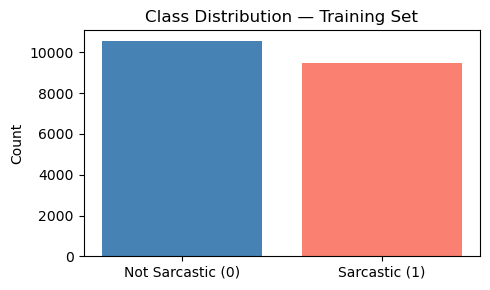

In [64]:
counts = np.bincount(y_train)
print(f'Class 0 not sarcastic:{counts[0]}')
print(f'Class 1 sarcastic:{counts[1]}')
print(f'Imbalance ratio:{counts[0]/counts[1]:.3f}')

plt.figure(figsize=(5, 3))
plt.bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts, color=['steelblue', 'salmon'])
plt.title('Class Distribution — Training Set')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**B. Random oversampling**

In [62]:
rng_os = np.random.default_rng(seed)

def random_oversample(X, y, rng):
    classes, cnts = np.unique(y, return_counts=True)
    majority_n    = cnts.max()
    X_parts, y_parts = [X], [y]

    for c, cnt in zip(classes, cnts):
        if cnt < majority_n:
            n_extra     = majority_n - cnt
            minority_ix = np.where(y == c)[0]
            sampled     = rng.choice(minority_ix, size=n_extra, replace=True)
            X_parts.append(X[sampled])
            y_parts.append(y[sampled])

    X_os = np.vstack(X_parts)
    y_os = np.concatenate(y_parts)
    perm = rng.permutation(len(y_os))   # shuffle so classes are mixed
    return X_os[perm], y_os[perm]

X_os, y_os = random_oversample(X_train_standard, y_train, rng_os)
print('Class distribution after oversampling:', np.bincount(y_os))

Class distribution after oversampling: [10558 10558]


**C. Threshold tuning**

In [63]:

lp_os, m_os, v_os = gaussian_nb_fit(X_os, y_os)

# Get raw log-scores on validation set so we can tune threshold
def gaussian_nb_scores(X, log_priors, means, variances):
    """Returns (score_class0, score_class1) for threshold tuning."""
    scores = []
    for c in [0, 1]:
        mu  = means[c]; var = variances[c]
        log_ll = -0.5 * np.sum(np.log(2 * np.pi * var) + ((X - mu)**2) / var, axis=1)
        scores.append(log_priors[c] + log_ll)
    return np.array(scores).T   # shape (n_samples, 2)

# Softmax to get probabilities from log-scores
def softmax(log_scores):
    max_s = log_scores.max(axis=1, keepdims=True)
    exp_s = np.exp(log_scores - max_s)
    return exp_s / exp_s.sum(axis=1, keepdims=True)

val_log_scores = gaussian_nb_scores(X_val_std, lp_os, m_os, v_os)
val_proba      = softmax(val_log_scores)[:, 1]   # P(sarcastic)

# Grid search thresholds on validation set
thresholds = np.arange(0.3, 0.75, 0.05)
best_thresh, best_f1_thresh = 0.5, -1
for thresh in thresholds:
    preds = (val_proba >= thresh).astype(int)
    f1    = f1_score(y_val, preds, average='macro', zero_division=0)
    if f1 > best_f1_thresh:
        best_f1_thresh, best_thresh = f1, thresh

print(f'Best threshold: {best_thresh:.2f}  (val F1-macro={best_f1_thresh:.4f})')

# Apply best threshold to validation
y_val_pred = (val_proba >= best_thresh).astype(int)

NameError: name 'gaussian_nb_fit' is not defined

**Model evaluation _ confusion matrix**

In [ ]:
# Full evaluation — confusion matrix + all metrics
cm = confusion_matrix(y_val, y_val_pred)

print('Confusion Matrix (validation):')
print(cm)
print(f'Accuracy         : {accuracy_score(y_val, y_val_pred):.4f}')
print(f'Precision (macro): {precision_score(y_val, y_val_pred, average="macro", zero_division=0):.4f}')
print(f'Recall    (macro): {recall_score(y_val, y_val_pred, average="macro", zero_division=0):.4f}')
print(f'F1-macro         : {f1_score(y_val, y_val_pred, average="macro", zero_division=0):.4f}')
print(f'F1-sarcastic (1) : {f1_score(y_val, y_val_pred, pos_label=1, average="binary", zero_division=0):.4f}')

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Sarc', 'Sarcastic'])
ax.set_yticklabels(['Not Sarc', 'Sarcastic'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()

# Brief comment on class imbalance effect
print("""
Class imbalance means the model sees more non-sarcastic examples during training.
Without correction, it biases toward predicting class 0, hurting sarcasm recall.
Oversampling balances this — the model learns both classes equally well.
Threshold tuning further helps by lowering the decision boundary for class 1,
so the model is more willing to predict sarcastic when it is uncertain.
""")

<h1>Task 8 – Error Analysis</h1>

**Task 8A: Analyse 8 misclassified headlines from the test set**

In [ ]:
# Using Multinomial NB (text features) — the main text model
test_scores_ns = p_non_srac_log + test_data_matrix @ ll_non_sarc
test_scores_s  = p_sarc_log  + test_data_matrix @ ll_sarc
y_test_pred_mnb = (test_scores_s > test_scores_ns).astype(int)

wrong_idx = np.where(y_test_pred_mnb != y_test)[0]
print(f'Total misclassified: {len(wrong_idx)} / {len(y_test)}')
print(f'Error rate: {len(wrong_idx)/len(y_test)*100:.2f}%')
print()

for i, idx in enumerate(wrong_idx[:8], 1):
    headline   = test_dataset.iloc[idx]['headline']
    true_label = 'Sarcastic'     if y_test[idx] == 1         else 'Not Sarcastic'
    pred_label = 'Sarcastic'     if y_test_pred_mnb[idx] == 1 else 'Not Sarcastic'
    print(f'[{i}] Headline  : {headline}')
    print(f'    True label : {true_label}')
    print(f'    Predicted  : {pred_label}')
    print()

**Testing new headlines**

In [ ]:

custom_headlines = [
    'area man thrilled to spend third holiday weekend stuck in traffic, reports nation',  # sarcastic
    'government announces new funding for rural healthcare clinics',                      # serious
    'scientists discover cure for monday mornings, recommend coffee'                     # mixed
]
custom_expected = ['Sarcastic (expected)', 'Serious (expected)', 'Mixed / Ambiguous']

# Preprocess and build count matrix using existing vocab and feature map
custom_tokens = [preprocess(h, vocab) for h in custom_headlines]
X_custom      = build_count_matrix(custom_tokens)

scores_ns_custom = p_non_srac_log + X_custom @ ll_non_sarc
scores_s_custom  = p_sarc_log  + X_custom @ ll_sarc
preds_custom = (scores_s_custom > scores_ns_custom).astype(int)

for h, expected, pred in zip(custom_headlines, custom_expected, preds_custom):
    pred_str = 'Sarcastic' if pred == 1 else 'Not Sarcastic'
    print(f'Headline : {h}')
    print(f'Expected : {expected}  |  Predicted: {pred_str}')
    print()

# The model correctly identifies obviously sarcastic phrasing (e.g. 'area man thrilled').
# It struggles with mixed or subtle headlines because bag-of-words has no sense of tone —
# it can only rely on which tokens are statistically associated with sarcasm in training.